# Multiplots: stacking plots into a single ortho

The `OrthoMapGroup` class composites several plots — typically **the same site
captured across a range of depths** — into one orthographic figure. Each plot
keeps its own real-world scale and orientation; the group only *repositions*
them, stacking the plots vertically by depth (shallowest on top, deepest at the
bottom) at a single shared metres-per-pixel scale.

This tutorial builds a depth transect for one Curaçao site (`cur_sna`, five
plots surveyed in 2020 between 5 m and 60 m) with per-plot coral annotations
overlaid and a colour legend.

## The workflow

1. **Load** each plot as a project and clean up stray points.
2. **Attach annotations** from a single combined file, split per plot.
3. **Build** the `OrthoMapGroup`.
4. **Render** and save.

The paths below are examples — point them at your own data. `reset_paths_to_local`
is only needed when the project files reference a different machine; drop it when
running where the data actually lives.

In [1]:
import glob, os
from substrata import *

PLOTS_DIR = "/mnt/sdd/curacao_focal/"
ANN_CSV = "/home/pimbongaerts/Documents/curacao_measures/annotations_simplified.csv"

# The five 2020 cur_sna_* plots (excludes the 2023 re-surveys)
plot_dirs = sorted(
    d for d in glob.glob(os.path.join(PLOTS_DIR, "cur_sna_*_2020*"))
    if os.path.isdir(d)
)
plot_dirs

['/mnt/sdd/curacao_focal/cur_sna_05m_20200303',
 '/mnt/sdd/curacao_focal/cur_sna_10m_20200303',
 '/mnt/sdd/curacao_focal/cur_sna_20m_20200303',
 '/mnt/sdd/curacao_focal/cur_sna_40m_20200216',
 '/mnt/sdd/curacao_focal/cur_sna_60m_20200216']

## 1. Load each plot and clean its point cloud

Every plot directory is a *project* that `ProjectInitializer` loads — point
cloud, cameras, scalebar markers, and the saved world transform that scales and
orients the reconstruction. `PointCloud.remove_stray_xy_points()` then trims the
sparse outer fringe so each plot's bounding box reflects the real reef surface
rather than a few far-flung points; that keeps the stacked tiles tight and
comparable. Raise `density_frac` to cull more aggressively.

In [2]:
plots = []
for d in plot_dirs:
    p = ProjectInitializer(path=d)
    p.reset_paths_to_local(d)                          # drop when running on the server
    p.initialize()
    p.pcd.remove_stray_xy_points(density_frac=0.3)     # cull sparse fringe points
    plots.append(p)

Loading project from YAML file: /mnt/sdd/curacao_focal/cur_sna_05m_20200303/cur_sna_05m_20200303.yaml
Loading pointcloud from /mnt/sdd/curacao_focal/cur_sna_05m_20200303/cur_sna_05m_20200303_dec50M.ply


No calibration found for sensor 0, skipping...
No calibration found for sensor 1, skipping...


Loading cameras from /mnt/sdd/curacao_focal/cur_sna_05m_20200303/cur_sna_05m_20200303.meta.json and /mnt/sdd/curacao_focal/cur_sna_05m_20200303/cur_sna_05m_20200303.cams.xml
Loading markers from /mnt/sdd/curacao_focal/cur_sna_05m_20200303/cur_sna_05m_20200303_markers.csv
Applying world_transform to loaded objects:
[[ 0.10474654  0.19735279 -0.03608354 10.61116112]
 [-0.20008267  0.0997709  -0.03513799  4.69362604]
 [-0.01473335  0.04816252  0.22064742 -4.23281323]
 [ 0.          0.          0.          1.        ]]
Loading project from YAML file: /mnt/sdd/curacao_focal/cur_sna_10m_20200303/cur_sna_10m_20200303.yaml
Loading pointcloud from /mnt/sdd/curacao_focal/cur_sna_10m_20200303/cur_sna_10m_20200303_dec50M.ply
Loading cameras from /mnt/sdd/curacao_focal/cur_sna_10m_20200303/cur_sna_10m_20200303.meta.json and /mnt/sdd/curacao_focal/cur_sna_10m_20200303/cur_sna_10m_20200303.cams.xml
Loading markers from /mnt/sdd/curacao_focal/cur_sna_10m_20200303/cur_sna_10m_20200303_markers.csv
Apply

## 2. Attach annotations from one combined file

Instead of each plot's own annotation file, here a single combined CSV holds
annotations for many plots. Every annotation id starts with its plot's 11-character
key (e.g. `cur_sna_05m`), so `Annotations.subset_by_prefix()` pulls out just the
rows for each plot — and any non-`cur_sna` rows are dropped automatically.

`transform_coords(p.world_transform)` moves each subset into the same
oriented/scaled frame as its cloud (exactly what `ProjectInitializer` does to a
plot's own annotations). Keep that line only if the CSV stores *raw* coordinates;
drop it if the CSV already holds world coordinates. A plot with no matching
annotations becomes `None` and is simply skipped in the overlay.

In [3]:
all_anns = Annotations(ANN_CSV, orig_coords_only=True)

plot_anns = []
for p, d in zip(plots, plot_dirs):
    prefix = os.path.basename(d)[:11]              # "cur_sna_05m", ...
    sub = all_anns.subset_by_prefix(prefix)
    sub.transform_coords(p.world_transform)        # match the plot's oriented cloud
    plot_anns.append(sub if len(sub) else None)

## 3. Build the stacked ortho

`OrthoMapGroup` rasterizes every cloud into one shared frame. The plots may be
passed in any order — they are stacked shallow-to-deep automatically (by mean
depth along the world up-vector).

Key parameters:

- **`orient`** — `"slope"` views each plot *face-on to its own best-fit plane*,
  removing the foreshortening a straight-down view imposes on steep plots, with
  no in-plane spin; `"topdown"` (default) projects straight down.
- **`vertical_spacing`** — gap in metres between stacked plots.
- **`align`** — horizontal alignment: `"centroid"` (default), `"center"`,
  `"left"`, or `"right"`.
- **`names`** — per-plot labels drawn beside each tile.
- **`order`** — override the automatic depth ordering with an explicit list of
  plot indices (top to bottom).
- **`arrange`** — `"stack"` (default) or `None` to composite the clouds at their
  true world coordinates (for plots that are already co-registered).
- **`pixel_height`** / **`pixel_width`** — output resolution; prefer
  `pixel_height` for a tall vertical stack.

In [4]:
grp = OrthoMapGroup(
    [p.pcd for p in plots],
    pixel_height=6000,
    vertical_spacing=1.0,
    orient="slope",                    # face-on; use "topdown" for a straight-down view
    names=[os.path.basename(d)[:11] for d in plot_dirs],
)

Rasterizing (4532x6000 px): 100%|████████████████████████████████████████████████████████| 101/101 [00:12<00:00,  7.83it/s]


## 4. Render

`show()` overlays the annotations and returns a PIL image. Pass annotations as a
**per-plot list** parallel to the plots — each set moves with its plot.

Rendering options:

- **`show_labels=True`** — draw the plot `names` in a narrow left gutter
  (vertical by default; `label_rotation=0` for horizontal). Pass
  **`show_labels=False`** to hide the per-plot labels entirely.
- **`image_opacity=1.0`** — fade the reef imagery toward the white background so
  the annotation markers stand out. `1.0` (default) leaves it unchanged, `0.0`
  hides the imagery completely (markers only); e.g. `image_opacity=0.5` for a
  half-faded backdrop.
- **`legend=True`** — append a colour legend of the annotation labels.
- **`color_by="label"`** (default) — colour markers by annotation label,
  consistently across every plot. `label_colors={label: (r, g, b)}` pins a fixed
  scheme applied to both markers and legend.
- **`point_size`** / **`point_size_metres`** — marker size in pixels or metres
  (both auto-scale to the composite by default).
- **`font_size`** — label text size.

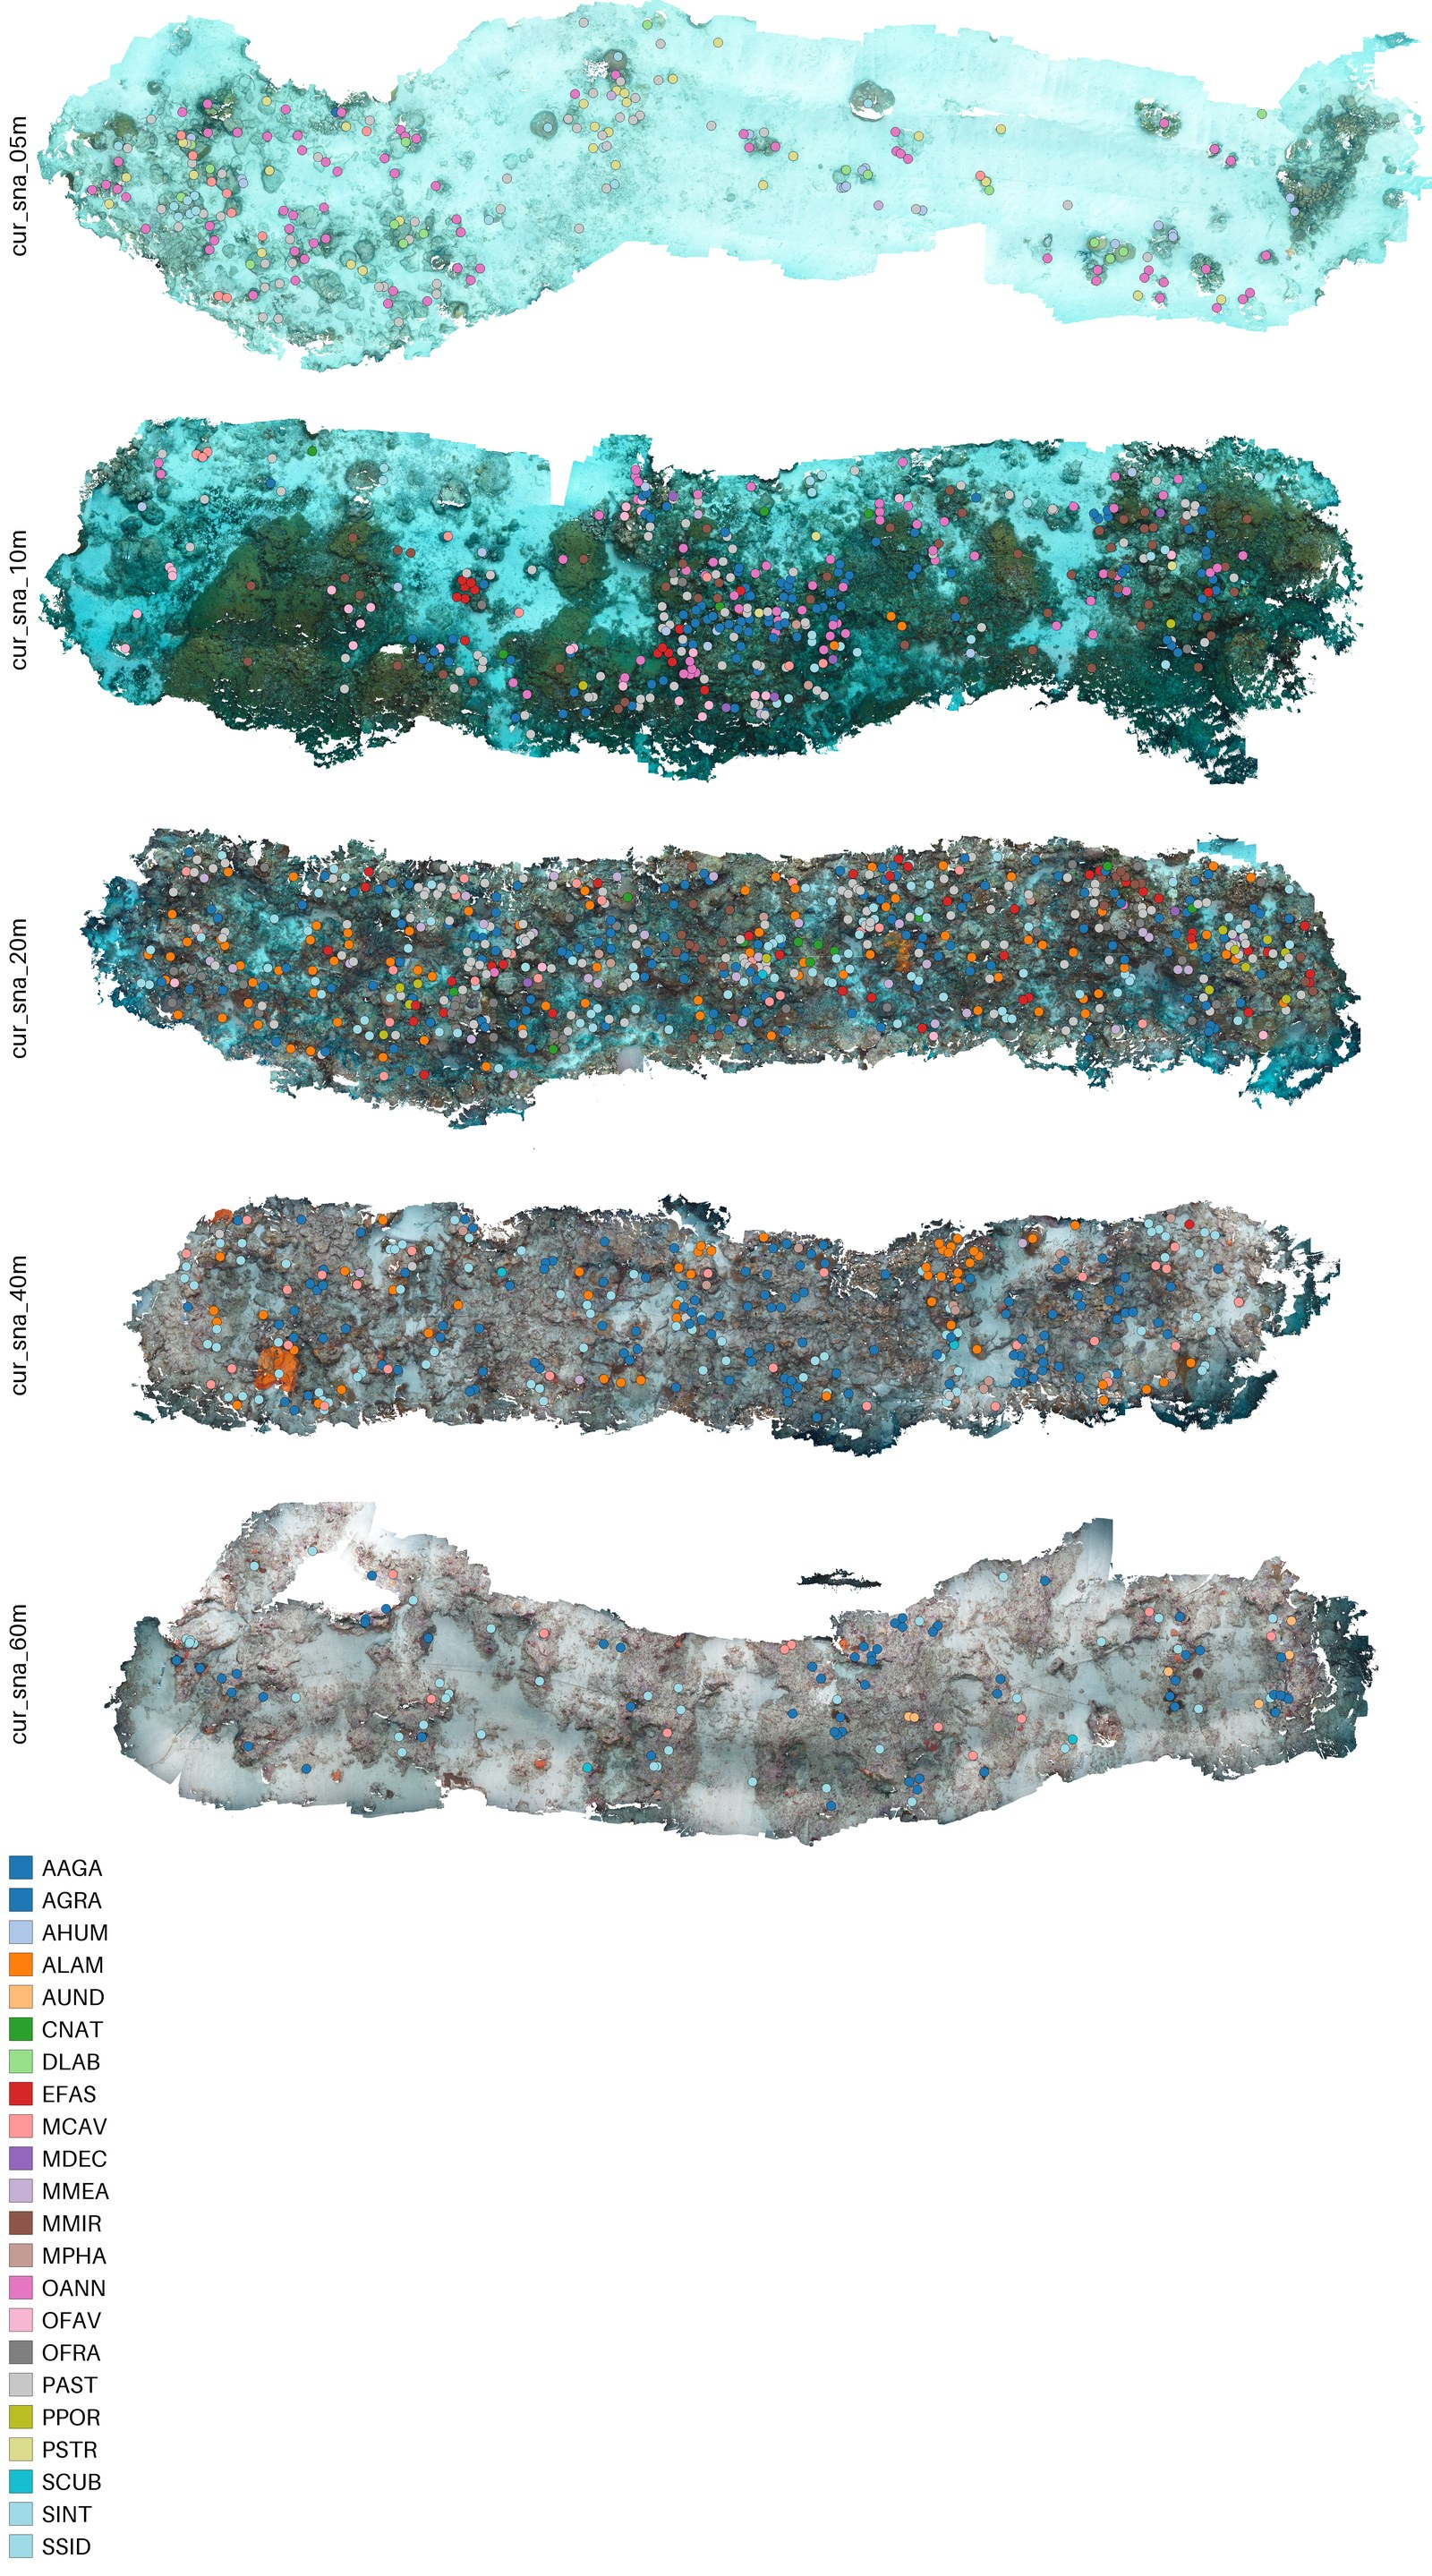

In [5]:
img = grp.show(plot_anns, show_labels=True, legend=True)
img

## Saving

`show()` returns a PIL image, so save it directly — PNG keeps the markers and
labels crisp:

```python
img.save("cur_sna_2020_stack.png")
```

For a smaller file, render at a display size before saving
(`grp.show(..., width=1500)`), or use `img.save("out.jpg", quality=95)`.

## Where to go next

- Swap `orient="slope"` for `"topdown"` to compare the two projections.
- Drop `arrange="stack"` (`arrange=None`) to composite already co-registered
  clouds at their true coordinates instead of stacking them.
- Feed measurement outputs instead of raw annotations to map any per-point
  quantity across the depth transect.